# TS7 (Filtrado digital lineal de ECG)

Diseño de filtros para acondicionar una señal de ECG, comparando cuatro métodos sobre una misma plantilla pasa-banda:
- Butterworth (IIR, máximamente plano)
- Chebyshev Tipo I (IIR, con ripple en la banda de paso)
- FIR por método de ventanas (ventana de Kaiser)
- FIR por cuadrados mínimos (firls)

El bonus aplica los mismos cuatro métodos como pasa-bajos promediadores sobre la serie de temperatura del aire de Buenos Aires (2024) para extraer la tendencia estacional.

In [27]:
import numpy as np
import pandas as pd
from scipy import signal as sig
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

## Carga de la señal

La señal de ECG fue registrada a una frecuencia de muestreo de fs = 1000 Hz (Nyquist = 500 Hz).

In [28]:
# Muestreo
fs = 1000
nyq = fs / 2

# Carga de señal
mat_struct = sio.loadmat('./signals/ecg.mat')
ecg = mat_struct['ecg_lead'].flatten().astype(float)
t = np.arange(len(ecg)) / fs

## Plantilla de diseño (filtro pasa-banda)

Se elige un pasa-banda porque el enunciado pide dos cosas, una por cada borde:

1. Nivel isoeléctrico nulo: borde inferior (`ws1 = 0.1`, `wp1 = 1` Hz): atenúa la deriva de línea de base (respiración / electrodos, < 1 Hz), llevando la señal a cero entre latidos.

2. Trazos suaves: borde superior (`wp2 = 35`, `ws2 = 45` Hz): elimina el ruido de alta frecuencia (EMG y red de 50 Hz) sin recortar el contenido útil del QRS (la energía del ECG está por debajo de ~35 Hz).

Tolerancias: 1 dB de ripple en banda de paso (`gpass`) y 40 dB de atenuación en rechazo (`gstop`).

In [29]:
ws1, wp1, wp2, ws2 = 0.1, 1.0, 35.0, 45.0
gpass, gstop = 1.0, 40.0

## Filtros IIR: Butterworth y Chebyshev Tipo I

Ambos se diseñan sobre la misma plantilla. La función `*ord` devuelve el orden mínimo que cumple las tolerancias y la frecuencia natural; el filtro se construye en formato SOS (secciones de segundo orden) por estabilidad numérica y se aplica con `sosfiltfilt` (filtrado bidireccional, fase cero).

In [30]:
# Configuración de filtro, Butterworth
N, wn = sig.buttord([wp1, wp2], [ws1, ws2], gpass, gstop, fs=fs)
sos = sig.butter(N, wn, btype='bandpass', output='sos', fs=fs)
ecg_f = sig.sosfiltfilt(sos, ecg)

# Configuración de filtro, Chebyshev tipo I
ripple_db = 1.0
N_cheb, wn_cheb = sig.cheb1ord([wp1, wp2], [ws1, ws2], gpass, gstop, fs=fs)
sos_cheb = sig.cheby1(N_cheb, ripple_db, wn_cheb, btype='bandpass', output='sos', fs=fs)
ecg_f_cheb = sig.sosfiltfilt(sos_cheb, ecg)

## Filtros FIR sobre la misma plantilla

Se respeta el mismo pasa-banda (mismos bordes y tolerancias). El borde inferior (0.1–1 Hz) impone la transición más angosta y, por lo tanto, la cantidad de coeficientes necesarios. Se estima con la fórmula de Kaiser a partir de la atenuación de rechazo (`gstop`) y el ancho de transición normalizado a Nyquist. Se fuerza orden impar (FIR tipo I).

Método de ventanas (firwin): las frecuencias de corte se ubican en el centro de cada banda de transición.

Método de cuadrados mínimos (firls): se definen bandas contiguas, describiendo las transiciones como rampas lineales. Si se dejaran huecos "don't care" entre el paso y el rechazo, `firls` no controla esas zonas y, con tantos coeficientes, aparecen ripples enormes (sobre-picos de decenas de dB) en la banda de transición 35–45 Hz.

In [31]:
trans_width = min(wp1 - ws1, ws2 - wp2)        # transición más angosta [Hz]
numtaps, beta = sig.kaiserord(gstop, trans_width / nyq)
numtaps |= 1                                   # fuerzo orden impar (FIR tipo I)

# Método de ventanas (firwin con ventana de Kaiser)
cutoff = [(ws1 + wp1) / 2, (wp2 + ws2) / 2]
fir_win = sig.firwin(numtaps, cutoff, window=('kaiser', beta),
                     pass_zero=False, fs=fs)
ecg_f_win = sig.filtfilt(fir_win, 1.0, ecg)

# Método de cuadrados mínimos (firls)
bands   = [0, ws1, ws1, wp1, wp1, wp2, wp2, ws2, ws2, nyq]
desired = [0, 0,   0,   1,   1,   1,   1,   0,   0,   0]
fir_ls = sig.firls(numtaps, bands, desired, fs=fs)
ecg_f_ls = sig.filtfilt(fir_ls, 1.0, ecg)

## Respuestas en frecuencia

Para visualizar bien la plantilla se arma una grilla de frecuencias con mayor resolución en las zonas de interés: la banda baja (0.01–5 Hz, en escala logarítmica) y las dos bandas de transición.

In [32]:
# Aumento la resolución en las secciones de interés
f_low  = np.logspace(np.log10(0.01), np.log10(5), 3000)
f_t1   = np.linspace(ws1, wp1, 1000)
f_t2   = np.linspace(wp2, ws2, 1000)
f_rest = np.linspace(0.01, 80, 2000)
freqs = np.unique(np.concatenate([f_low, f_t1, f_t2, f_rest]))

### Butterworth

Respuesta máximamente plana en la banda de paso. Se muestra el ECG filtrado en el tiempo, la respuesta en frecuencia contra la plantilla (zonas de paso en verde, de rechazo en rojo) y un zoom al inicio de la banda de paso para verificar el ripple.

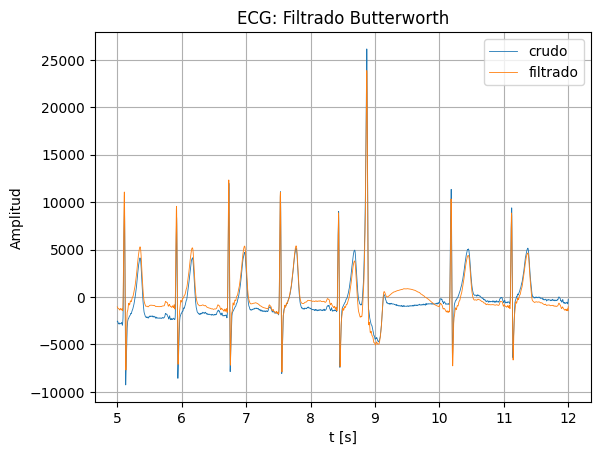

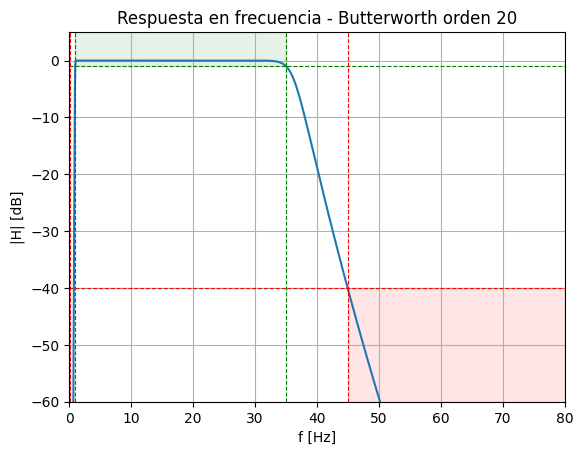

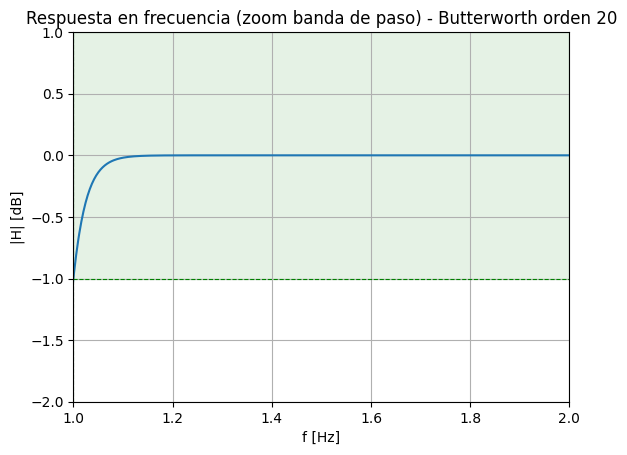

In [33]:
ini, fin = 5000, 12000
plt.figure()
plt.plot(t[ini:fin], ecg[ini:fin], lw=0.6, label='crudo')
plt.plot(t[ini:fin], ecg_f[ini:fin], lw=0.6, label='filtrado')
plt.title('ECG: Filtrado Butterworth')
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

w, h = sig.sosfreqz(sos, worN=freqs, fs=fs)
plt.figure()
plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
 
plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axhline(-gstop, color='r', ls='--', lw=0.8)
plt.axvline(ws1, color='r', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.axvline(wp2, color='g', ls='--', lw=0.8)
plt.axvline(ws2, color='r', ls='--', lw=0.8)
 
plt.fill_between([wp1, wp2], -gpass, 5, color='g', alpha=0.1)
plt.fill_between([0, ws1], -60, -gstop, color='r', alpha=0.1)
plt.fill_between([ws2, 80], -60, -gstop, color='r', alpha=0.1)
 
plt.title(f'Respuesta en frecuencia - Butterworth orden {N}')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(0, 80)
plt.ylim(-60, 5)
plt.grid(True)

# Zoom al inicio de la banda de paso - Butterworth
plt.figure()
plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.fill_between([wp1, 2], -gpass, 1, color='g', alpha=0.1)
plt.title(f'Respuesta en frecuencia (zoom banda de paso) - Butterworth orden {N}')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(1, 2)
plt.ylim(-2, 1)
plt.grid(True)

### Chebyshev Tipo I

Cumple la plantilla con un orden menor que Butterworth a costa de ripple en la banda de paso (visible en el zoom).

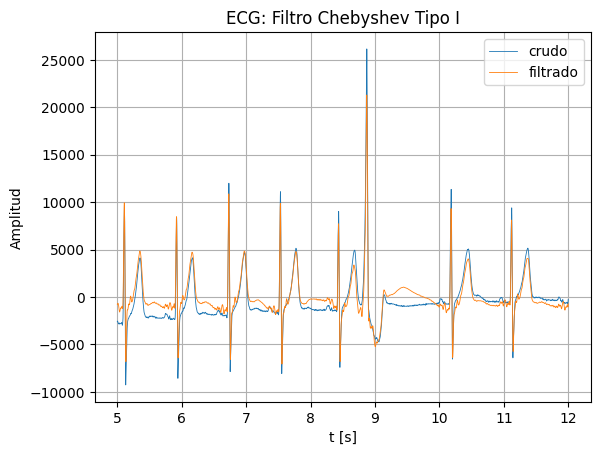

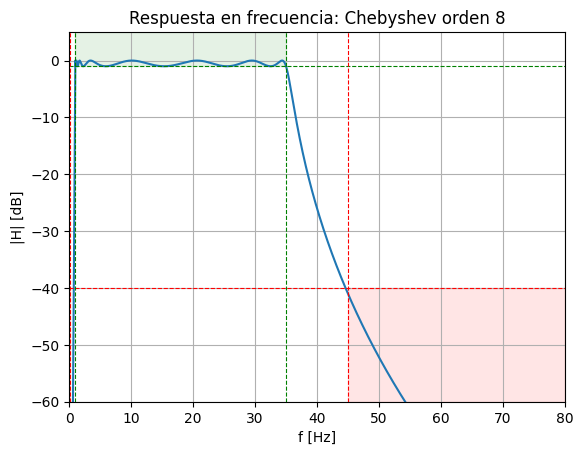

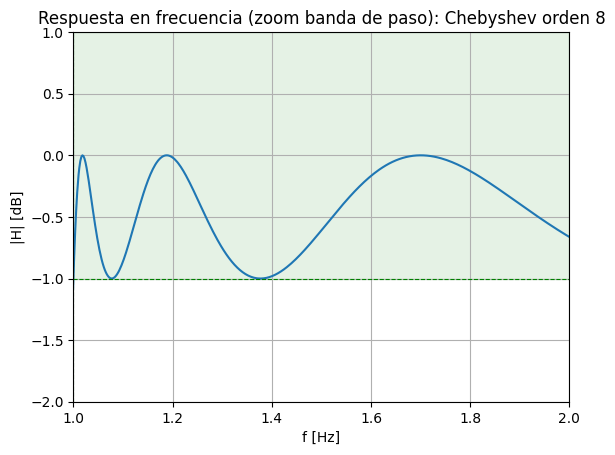

In [34]:
ini, fin = 5000, 12000
plt.figure()
plt.plot(t[ini:fin], ecg[ini:fin], lw=0.6, label='crudo')
plt.plot(t[ini:fin], ecg_f_cheb[ini:fin], lw=0.6, label='filtrado')
plt.title('ECG: Filtro Chebyshev Tipo I')
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

w_cheb, h_cheb = sig.sosfreqz(sos_cheb, worN=freqs, fs=fs)
plt.figure()
plt.plot(w_cheb, 20 * np.log10(np.abs(h_cheb) + 1e-12))
 
plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axhline(-gstop, color='r', ls='--', lw=0.8)
plt.axvline(ws1, color='r', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.axvline(wp2, color='g', ls='--', lw=0.8)
plt.axvline(ws2, color='r', ls='--', lw=0.8)
 
plt.fill_between([wp1, wp2], -gpass, 5, color='g', alpha=0.1)
plt.fill_between([0, ws1], -60, -gstop, color='r', alpha=0.1)
plt.fill_between([ws2, 80], -60, -gstop, color='r', alpha=0.1)
 
plt.title(f'Respuesta en frecuencia: Chebyshev orden {N_cheb}')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(0, 80)
plt.ylim(-60, 5)
plt.grid(True)

# Zoom al inicio de la banda de paso - Chebyshev Tipo I
plt.figure()
plt.plot(w_cheb, 20 * np.log10(np.abs(h_cheb) + 1e-12))
plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.fill_between([wp1, 2], -gpass, 1, color='g', alpha=0.1)
plt.title(f'Respuesta en frecuencia (zoom banda de paso): Chebyshev orden {N_cheb}')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(1, 2)
plt.ylim(-2, 1)
plt.grid(True)

### FIR: Método de ventanas (Kaiser)

FIR de fase lineal obtenido ventaneando la respuesta ideal con una ventana de Kaiser. El gran número de taps se debe a la transición angosta del borde inferior.

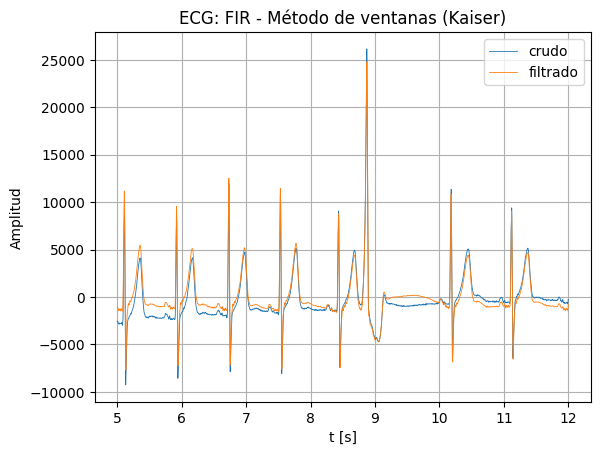

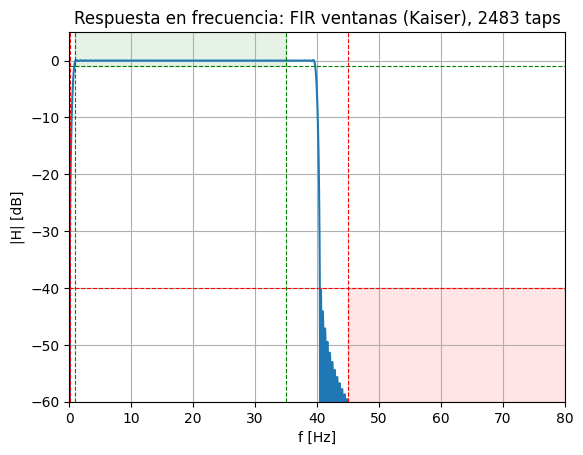

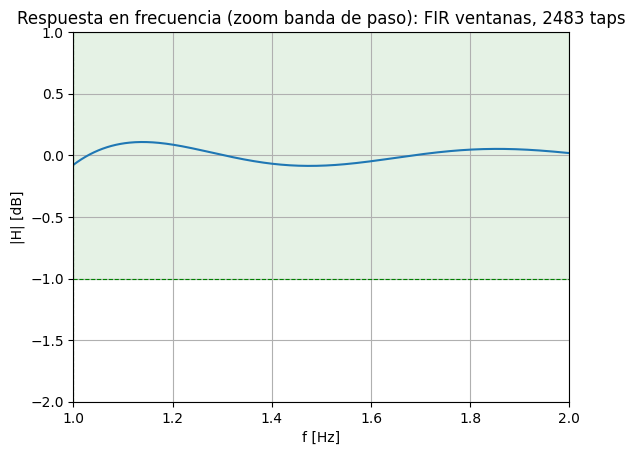

In [ ]:
ini, fin = 5000, 12000
plt.figure()
plt.plot(t[ini:fin], ecg[ini:fin], lw=0.6, label='crudo')
plt.plot(t[ini:fin], ecg_f_win[ini:fin], lw=0.6, label='filtrado')
plt.title('ECG: FIR - Método de ventanas (Kaiser)')
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

w_win, h_win = sig.freqz(fir_win, worN=freqs, fs=fs)
plt.figure()
plt.plot(w_win, 20 * np.log10(np.abs(h_win) + 1e-12))

plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axhline(-gstop, color='r', ls='--', lw=0.8)
plt.axvline(ws1, color='r', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.axvline(wp2, color='g', ls='--', lw=0.8)
plt.axvline(ws2, color='r', ls='--', lw=0.8)

plt.fill_between([wp1, wp2], -gpass, 5, color='g', alpha=0.1)
plt.fill_between([0, ws1], -60, -gstop, color='r', alpha=0.1)
plt.fill_between([ws2, 80], -60, -gstop, color='r', alpha=0.1)

plt.title(f'Respuesta en frecuencia: FIR ventanas (Kaiser)')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(0, 80)
plt.ylim(-60, 5)
plt.grid(True)

# Zoom al inicio de la banda de paso - FIR ventanas
plt.figure()
plt.plot(w_win, 20 * np.log10(np.abs(h_win) + 1e-12))
plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.fill_between([wp1, 2], -gpass, 1, color='g', alpha=0.1)
plt.title(f'Respuesta en frecuencia (zoom banda de paso): FIR ventanas')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(1, 2)
plt.ylim(-2, 1)
plt.grid(True)

### FIR - Método de cuadrados mínimos (firls)

FIR de fase lineal que minimiza el error cuadrático contra la respuesta deseada definida por bandas contiguas.

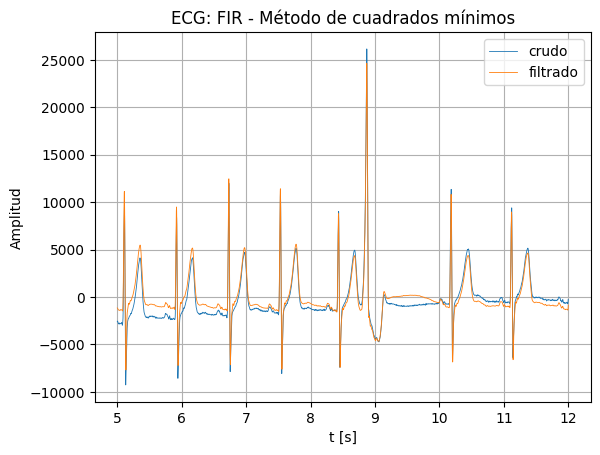

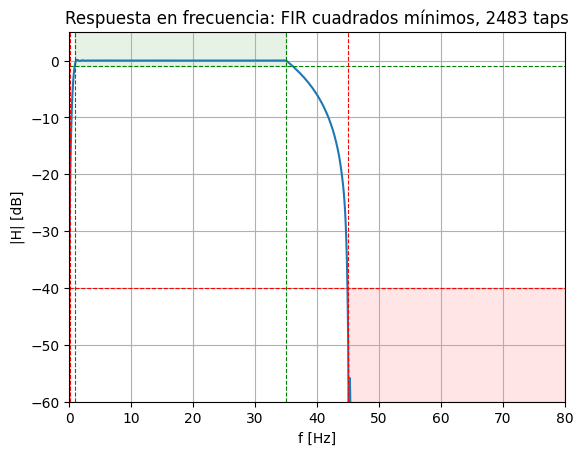

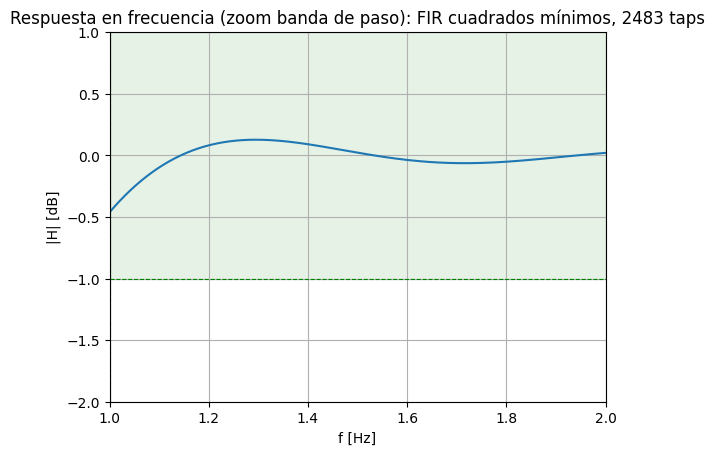

In [ ]:
ini, fin = 5000, 12000
plt.figure()
plt.plot(t[ini:fin], ecg[ini:fin], lw=0.6, label='crudo')
plt.plot(t[ini:fin], ecg_f_ls[ini:fin], lw=0.6, label='filtrado')
plt.title('ECG: FIR - Método de cuadrados mínimos')
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

w_ls, h_ls = sig.freqz(fir_ls, worN=freqs, fs=fs)
plt.figure()
plt.plot(w_ls, 20 * np.log10(np.abs(h_ls) + 1e-12))

plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axhline(-gstop, color='r', ls='--', lw=0.8)
plt.axvline(ws1, color='r', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.axvline(wp2, color='g', ls='--', lw=0.8)
plt.axvline(ws2, color='r', ls='--', lw=0.8)

plt.fill_between([wp1, wp2], -gpass, 5, color='g', alpha=0.1)
plt.fill_between([0, ws1], -60, -gstop, color='r', alpha=0.1)
plt.fill_between([ws2, 80], -60, -gstop, color='r', alpha=0.1)

plt.title(f'Respuesta en frecuencia: FIR cuadrados mínimos')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(0, 80)
plt.ylim(-60, 5)
plt.grid(True)

# Zoom al inicio de la banda de paso - FIR cuadrados mínimos
plt.figure()
plt.plot(w_ls, 20 * np.log10(np.abs(h_ls) + 1e-12))
plt.axhline(-gpass, color='g', ls='--', lw=0.8)
plt.axvline(wp1, color='g', ls='--', lw=0.8)
plt.fill_between([wp1, 2], -gpass, 1, color='g', alpha=0.1)
plt.title(f'Respuesta en frecuencia (zoom banda de paso): FIR cuadrados mínimos')
plt.xlabel('f [Hz]')
plt.ylabel('|H| [dB]')
plt.xlim(1, 2)
plt.ylim(-2, 1)
plt.grid(True)

## d) Evaluación de desempeño

Con los cuatro filtros ya caracterizados en frecuencia, se compara cada señal filtrada contra la cruda en regiones de interés:
1. CON interferencia → debe eliminar la deriva de línea de base / ruido.
2. SIN interferencia → debe ser inocuo (no deformar el latido).

Todos los filtros se aplicaron con filtrado bidireccional (`filtfilt` / `sosfiltfilt`), de fase cero: no introducen retardo, por lo que `demora = 0` y las señales quedan alineadas con la cruda sin necesidad de compensación.

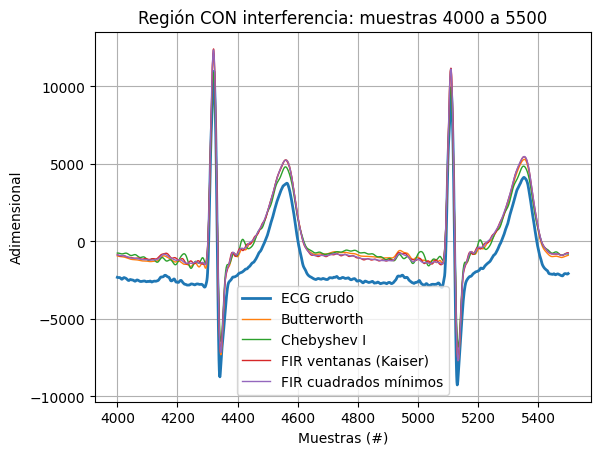

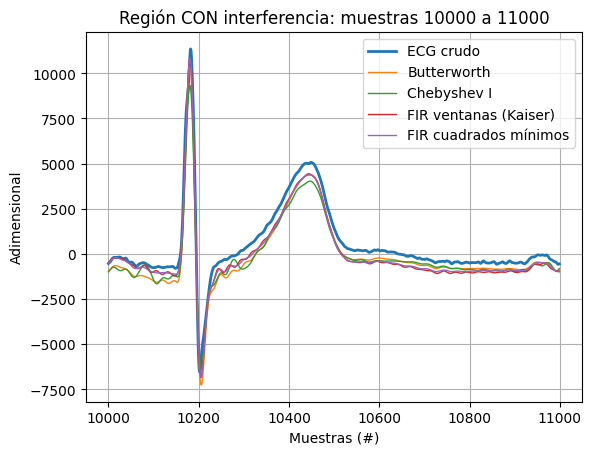

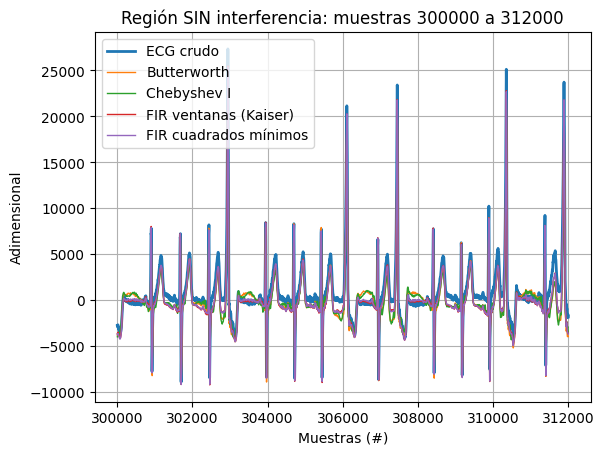

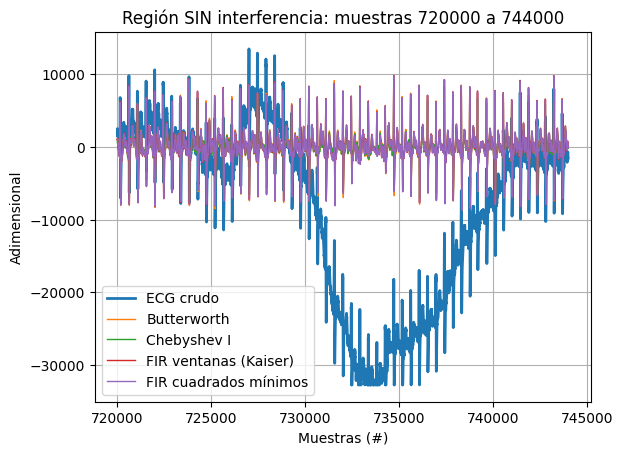

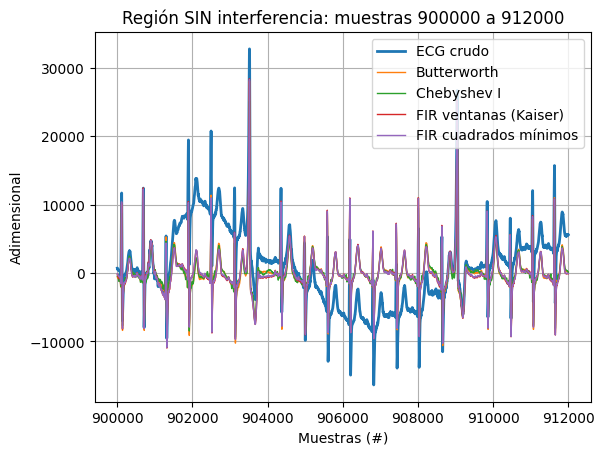

In [37]:
cant_muestras = len(ecg)
demora = 0

filtrados = [
    (ecg_f,      'Butterworth'),
    (ecg_f_cheb, 'Chebyshev I'),
    (ecg_f_win,  'FIR ventanas (Kaiser)'),
    (ecg_f_ls,   'FIR cuadrados mínimos'),
]

# Regiones CON interferencia
regs_con_ruido = (
    [4000, 5500],     # muestras
    [10000, 11000],   # muestras
)
for ii in regs_con_ruido:
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
    plt.figure()
    plt.plot(zoom_region, ecg[zoom_region], label='ECG crudo', lw=2)
    for y, nombre in filtrados:
        plt.plot(zoom_region, y[zoom_region + demora], label=nombre, lw=1)
    plt.title(f'Región CON interferencia: muestras {int(ii[0])} a {int(ii[1])}')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Adimensional')
    plt.legend()
    plt.grid(True)

# Regiones SIN interferencia
regs_sin_ruido = (
    np.array([5, 5.2]) * 60 * fs,    # minutos -> muestras
    np.array([12, 12.4]) * 60 * fs,  # minutos -> muestras
    np.array([15, 15.2]) * 60 * fs,  # minutos -> muestras
)
for ii in regs_sin_ruido:
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
    plt.figure()
    plt.plot(zoom_region, ecg[zoom_region], label='ECG crudo', lw=2)
    for y, nombre in filtrados:
        plt.plot(zoom_region, y[zoom_region + demora], label=nombre, lw=1)
    plt.title(f'Región SIN interferencia: muestras {int(ii[0])} a {int(ii[1])}')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Adimensional')
    plt.legend()
    plt.grid(True)

## Verificación del cumplimiento de la plantilla

Antes del bonus se arma una tabla que comprueba numéricamente si cada respuesta en frecuencia respeta la plantilla pasa-banda. Para cada filtro se busca el **peor caso** sobre una grilla densa de frecuencias hasta Nyquist:

- **Banda de paso** (`wp1`–`wp2` = 1–35 Hz): el peor caso es el **mínimo** de `|H|`; debe quedar **por encima** del umbral `-gpass = -1 dB`.
- **Banda de rechazo** (`f ≤ ws1 = 0.1 Hz` y `f ≥ ws2 = 45 Hz`): el peor caso es el **máximo** de `|H|`; debe quedar **por debajo** del umbral `-gstop = -40 dB`.

Se evalúa la respuesta de **una sola pasada** (la misma que se grafica contra la plantilla).

In [ ]:
# Grilla densa para buscar el peor caso (zona baja en log + resto lineal hasta Nyquist)
f_eval = np.unique(np.concatenate([
    np.logspace(np.log10(1e-3), np.log10(5), 5000),
    np.linspace(0, nyq, 40000),
]))

def _resp_db(filt, tipo):
    if tipo == 'sos':
        _, hh = sig.sosfreqz(filt, worN=f_eval, fs=fs)
    else:
        _, hh = sig.freqz(filt, worN=f_eval, fs=fs)
    return 20 * np.log10(np.abs(hh) + 1e-12)

filtros_resp = [
    ('Butterworth',           sos,      'sos'),
    ('Chebyshev I',           sos_cheb, 'sos'),
    ('FIR ventanas (Kaiser)', fir_win,  'fir'),
    ('FIR cuadrados mínimos', fir_ls,   'fir'),
]

# Paso: |H| debe mantenerse por ENCIMA de -gpass  -> peor caso = mínimo |H|
# Rechazo: |H| debe mantenerse por DEBAJO de -gstop -> peor caso = máximo |H|
mask_pass = (f_eval >= wp1) & (f_eval <= wp2)
mask_stop = (f_eval <= ws1) | (f_eval >= ws2)

filas = []
for nombre, filt, tipo in filtros_resp:
    Hdb = _resp_db(filt, tipo)
    ip  = np.argmin(Hdb[mask_pass])
    iss = np.argmax(Hdb[mask_stop])
    peor_pass, f_pass = Hdb[mask_pass][ip],  f_eval[mask_pass][ip]
    peor_stop, f_stop = Hdb[mask_stop][iss], f_eval[mask_stop][iss]
    cumple = (peor_pass >= -gpass) and (peor_stop <= -gstop)
    filas.append({
        'Filtro':                  nombre,
        'Peor |H| paso [dB]':      round(peor_pass, 2),
        'f peor paso [Hz]':        round(f_pass, 2),
        'Umbral paso [dB]':        -gpass,
        'Peor |H| rechazo [dB]':   round(peor_stop, 2),
        'f peor rechazo [Hz]':     round(f_stop, 2),
        'Umbral rechazo [dB]':     -gstop,
        'Cumple plantilla':        'Sí' if cumple else 'No',
    })

tabla_plantilla = pd.DataFrame(filas).set_index('Filtro')
tabla_plantilla

**Lectura de la tabla.** Los dos IIR cumplen la plantilla en una pasada: el peor caso de banda de paso toca el borde de -1 dB (por diseño de `buttord` / `cheb1ord`) y el rechazo supera los 40 dB en todos los bordes.

Los dos FIR **no alcanzan** los 40 dB en el borde inferior del rechazo (peor caso cerca de DC / `ws1 = 0.1 Hz`): ~-35.5 dB el de ventanas y ~-28.3 dB el de cuadrados mínimos. La causa es la transición inferior extremadamente angosta (0.1→1 Hz, `trans_width/nyq ≈ 0.0018`), que empuja el orden a 2483 taps y deja poco margen; además la estimación de Kaiser y la minimización L2 de `firls` no garantizan la atenuación pico exacta cerca de DC.

En la práctica no es un problema: los cuatro filtros se aplican con `filtfilt` / `sosfiltfilt` (fase cero, doble pasada), que **duplica la atenuación en dB**. El rechazo efectivo pasa a ~-71 dB (ventanas) y ~-57 dB (firls), holgadamente dentro de la plantilla. La contracara es que también se duplica el ripple de paso, por lo que los IIR quedan en ~-2 dB de paso efectivo.

# BONUS: Temperatura del aire en Buenos Aires (2024)

Naturaleza de los datos:
- Variable: temperatura del aire en superficie [°C].
- Lugar: estación AEROPARQUE JORGE NEWBERY (SABE, ID 87582099999), Buenos Aires, Argentina → hemisferio sur (verano Dic–Mar).
- Período: año 2024 completo (366 días, bisiesto) → 8784 muestras.
- Muestreo: horario, `fs = 24` muestras/día (Nyquist = 12 ciclos/día). Las observaciones METAR son ~horarias irregulares; al descargar se remuestrearon a rejilla uniforme y se interpolaron huecos.
- Fuente: NOAA / NCEI, Integrated Surface Database (ISD), producto "global-hourly".

Selección de la plantilla:

El objetivo es un pasa-bajos que actúe como "promediador" y deje ver la tendencia estacional, separándola del ciclo diario (1 ciclo/día) y de las fluctuaciones meteorológicas (días). Por eso se piden dos cortes:
- "30 días": `fc = 1/30` ciclo/día → tendencia estacional.
- "5 días": `fc = 1/5` ciclo/día → suaviza el día a día, conserva olas de calor/frío de pocos días.

Cada plantilla se arma geométricamente alrededor de `fc` con un factor `r = 1.5`:
- `fpass = fc/r` (banda de paso, períodos largos)
- `fstop = fc*r` (banda de rechazo, períodos cortos)

Tolerancias: `gpass = 1` dB, `gstop = 20` dB.

In [38]:
df_temp = pd.read_csv('./temperature_data/buenos_aires_2024.csv',
                      parse_dates=['TIME'], index_col='TIME')
temp = df_temp['TEMP'].interpolate(limit_direction='both').to_numpy()
t_temp = df_temp.index

fs_temp = 24.0          # muestras por día (horario)
nyq_temp = fs_temp / 2
gpass_t, gstop_t = 1.0, 20.0

def plantilla_lp(Tc, r=1.5):
    """Bordes (fpass, fstop) de un pasa-bajos centrado en fc = 1/Tc [ciclo/día]."""
    fc = 1.0 / Tc
    return fc / r, fc * r

fpass30, fstop30 = plantilla_lp(30)
fpass5,  fstop5  = plantilla_lp(5)

## Los cuatro filtros como pasa-bajos de fase cero

Se reutilizan los mismos métodos del ECG, ahora como pasa-bajos. En `firls` se normaliza a ganancia 1 en DC (`b /= b.sum()`), como corresponde a un promediador.

In [39]:
def lp_butter(x, fp, fst):
    N, wn = sig.buttord(fp, fst, gpass_t, gstop_t, fs=fs_temp)
    sos = sig.butter(N, wn, btype='low', output='sos', fs=fs_temp)
    return sig.sosfiltfilt(sos, x)

def lp_cheby(x, fp, fst):
    N, wn = sig.cheb1ord(fp, fst, gpass_t, gstop_t, fs=fs_temp)
    sos = sig.cheby1(N, gpass_t, wn, btype='low', output='sos', fs=fs_temp)
    return sig.sosfiltfilt(sos, x)

def lp_firwin(x, fp, fst):
    nt, beta = sig.kaiserord(gstop_t, (fst - fp) / nyq_temp)
    nt |= 1
    b = sig.firwin(nt, (fp + fst) / 2, window=('kaiser', beta), fs=fs_temp)
    return sig.filtfilt(b, 1.0, x)

def lp_firls(x, fp, fst):
    nt, _ = sig.kaiserord(gstop_t, (fst - fp) / nyq_temp)
    nt |= 1
    bands   = [0, fp, fp, fst, fst, nyq_temp]
    desired = [1, 1, 1,  0,   0,   0]
    b = sig.firls(nt, bands, desired, fs=fs_temp)
    b /= b.sum()   # normalizo a ganancia 1 en DC (promediador)
    return sig.filtfilt(b, 1.0, x)

metodos = [
    ('butter', 'Butterworth',          lp_butter),
    ('cheby',  'Chebyshev I',          lp_cheby),
    ('firwin', 'FIR ventanas (Kaiser)', lp_firwin),
    ('firls',  'FIR cuadrados mínimos', lp_firls),
]

## Gráficos de temperatura promediada

Cada panel muestra la serie cruda (horaria) junto con los promedios de ~5 y ~30 días obtenidos con ese método.

Text(0.5, 0.98, 'Buenos Aires 2024: pasa-bajos promediadores (4 métodos, cortes 5 y 30 días)')

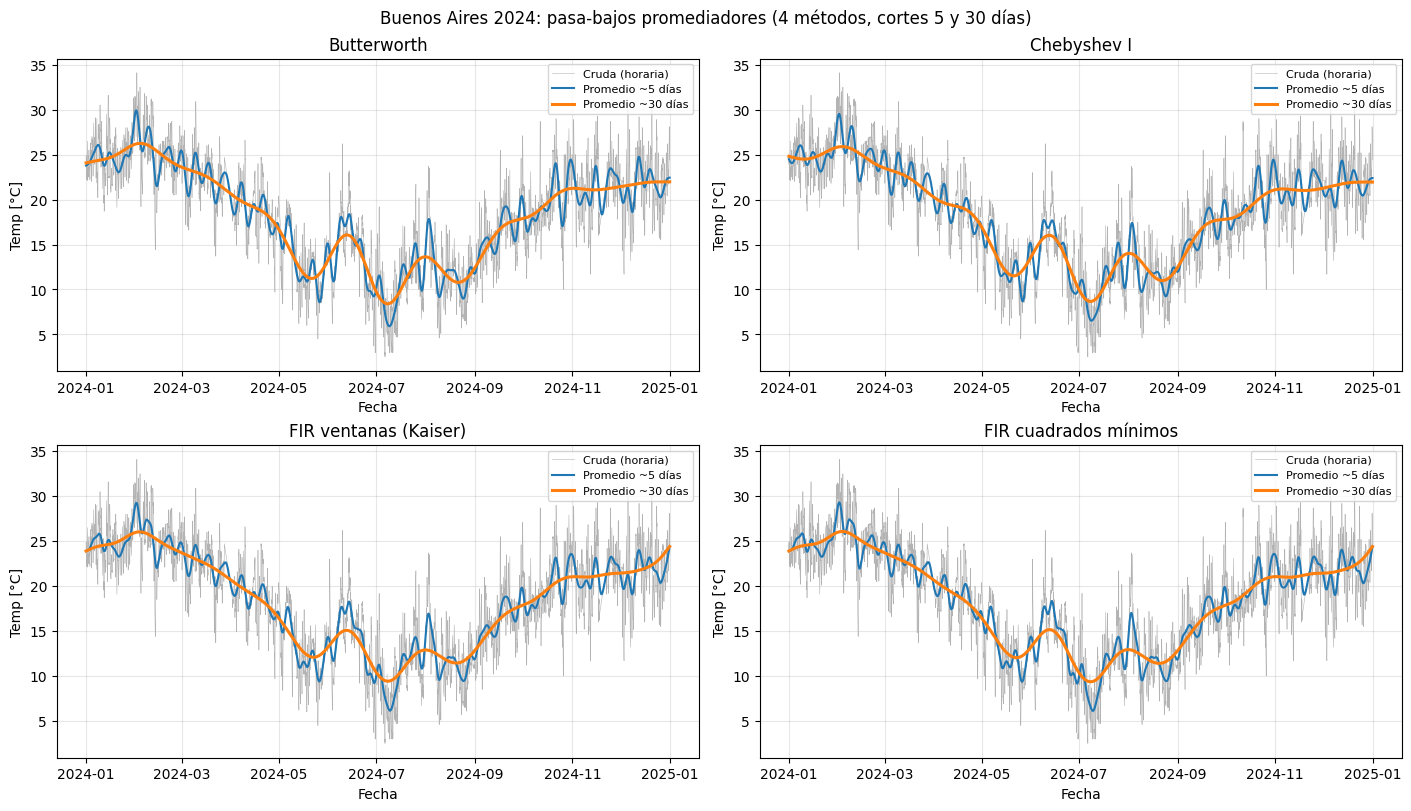

In [40]:
fig, axd = plt.subplot_mosaic([['butter', 'cheby'], ['firwin', 'firls']],
                              figsize=(14, 8), constrained_layout=True)
for clave, nombre, func in metodos:
    ax = axd[clave]
    ax.plot(t_temp, temp, lw=0.4, color='0.7', label='Cruda (horaria)')
    ax.plot(t_temp, func(temp, fpass5,  fstop5),  lw=1.5, color='tab:blue',
            label='Promedio ~5 días')
    ax.plot(t_temp, func(temp, fpass30, fstop30), lw=2.2, color='tab:orange',
            label='Promedio ~30 días')
    ax.set_title(nombre)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Temp [°C]')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('Buenos Aires 2024: pasa-bajos promediadores (4 métodos, cortes 5 y 30 días)')

## Tendencia estacional (Butterworth, corte 30 días)

Se superpone la tendencia de 30 días sobre las cuatro estaciones del hemisferio sur para verificar que el filtro promediador recupera el ciclo anual de temperatura.

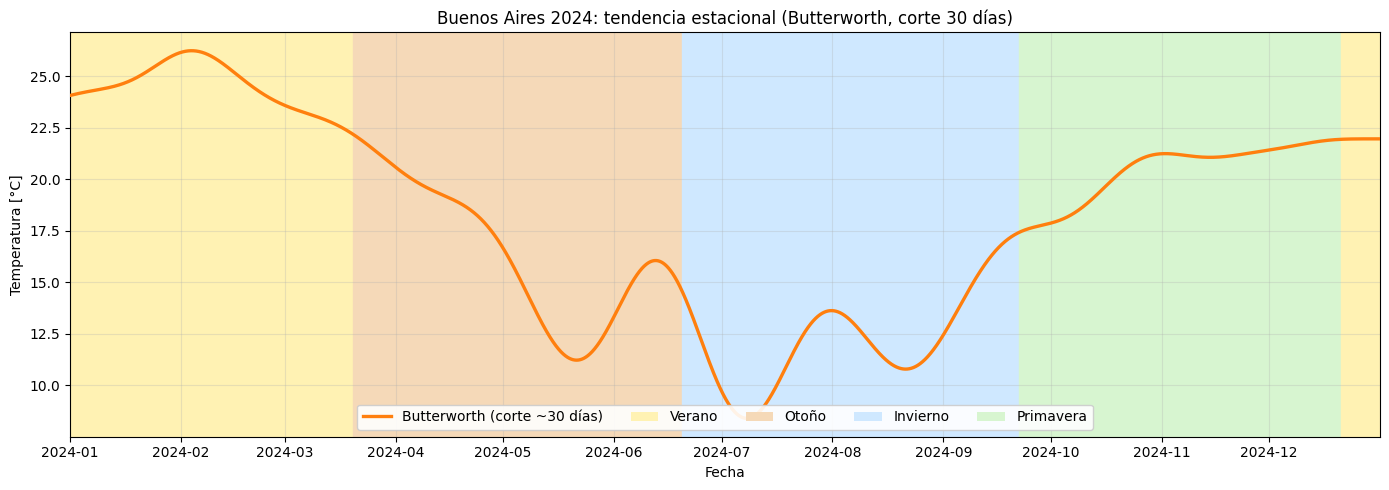

In [41]:
temp_butter30 = lp_butter(temp, fpass30, fstop30)
estaciones = [   # HEMISFERIO SUR
    ("2024-01-01", "2024-03-20", "Verano",    "#fff2b3"),
    ("2024-03-20", "2024-06-20", "Otoño",     "#f5d9b8"),
    ("2024-06-20", "2024-09-22", "Invierno",  "#cfe8ff"),
    ("2024-09-22", "2024-12-21", "Primavera", "#d7f5d0"),
    ("2024-12-21", "2025-01-01", "Verano",    "#fff2b3"),
]
plt.figure(figsize=(14, 5))
for ini, fin, nombre, color in estaciones:
    plt.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color=color, zorder=0)
linea, = plt.plot(t_temp, temp_butter30, lw=2.4, color='tab:orange',
                  label='Butterworth (corte ~30 días)', zorder=3)
plt.title('Buenos Aires 2024: tendencia estacional (Butterworth, corte 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Temperatura [°C]')
plt.xlim(t_temp.min(), t_temp.max())
parches = [Patch(facecolor=c, label=n)
           for n, c in dict((n, c) for _, _, n, c in estaciones).items()]
plt.legend(handles=[linea] + parches, loc='lower center', ncol=5, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()